# Successive Jump and Mode Decomposition (SJMD / SMJMD)

This notebook demonstrates **Successive Jump and Mode Decomposition (SJMD)** and its multivariate form **SMJMD**.

Unlike joint JMD / MJMD (which require a preset mode count K), SJMD extracts AM–FM modes **one by one** while jointly estimating a discontinuous jump, and stops automatically.

PySDKit exposes a single class SJMD that handles both:

- univariate input (N,) / (1, N) → SJMD
- multivariate input (C, N) → SMJMD (SMJMD is an alias of SJMD)

**Reference**

> M. Nazari, A. R. Korshøj, N. ur Rehman.  
> *Successive Jump and Mode Decomposition.*  
> arXiv:2504.08453.  
> [https://arxiv.org/abs/2504.08453](https://arxiv.org/abs/2504.08453)


## 1. Imports


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SJMD, SMJMD

print(SJMD())
print(SMJMD is SJMD)


Successive Jump and Mode Decomposition (SJMD / SMJMD)
True


## 2. Multivariate example (SMJMD)

Synthetic 3-channel signal following the authors' SJMD_test.m:

- shared low-frequency tone (~2 Hz) on all channels
- higher-frequency tone (~40 Hz) on channels 1–2
- piecewise jump on channels 1 and 3
- light Gaussian noise


In [3]:
rng = np.random.default_rng(0)
n = 256
t = np.arange(n, dtype=float) / n

# piecewise jump (stand-in for jump1.mat used in the MATLAB demo)
jump = np.zeros(n)
jump[n // 5 :] += 1.0
jump[2 * n // 5 :] -= 0.6
jump[3 * n // 5 :] += 0.9
jump[4 * n // 5 :] -= 0.4
jump_mc = np.vstack([10 * jump, np.zeros(n), 10 * jump])

ch1 = 5.0 * np.cos(2 * np.pi * 2 * t) + 2.0 * np.cos(2 * np.pi * 40 * t)
ch2 = 5.0 * np.cos(2 * np.pi * 2 * t) + 2.0 * np.cos(2 * np.pi * 40 * t)
ch3 = 5.0 * np.cos(2 * np.pi * 2 * t)
osc = np.vstack([ch1, ch2, ch3])

Sig = osc + jump_mc + 0.1 * rng.standard_normal((3, n))
print("Sig shape (C, N):", Sig.shape)


Sig shape (C, N): (3, 256)


In [4]:
# Parameters aligned with SJMD_test.m
sjmd = SJMD(
    max_alpha=80000,
    tau=50,
    beta=0.5,
    b_bar=0.9,
    stopc=4,   # power of the last mode (recommended)
    tol=1e-5,
)

u, J = sjmd.fit_transform(Sig, return_all=True)
print("modes (K, N, C):", u.shape)
print("jump  (C, N):   ", J.shape)
print("omega:         ", sjmd.omega)

modes (K, N, C): (6, 256, 3)
jump  (C, N):    (3, 256)
omega:          [0.00195333 0.00781253 0.00781258 0.01169936 0.02091715 0.15624222]


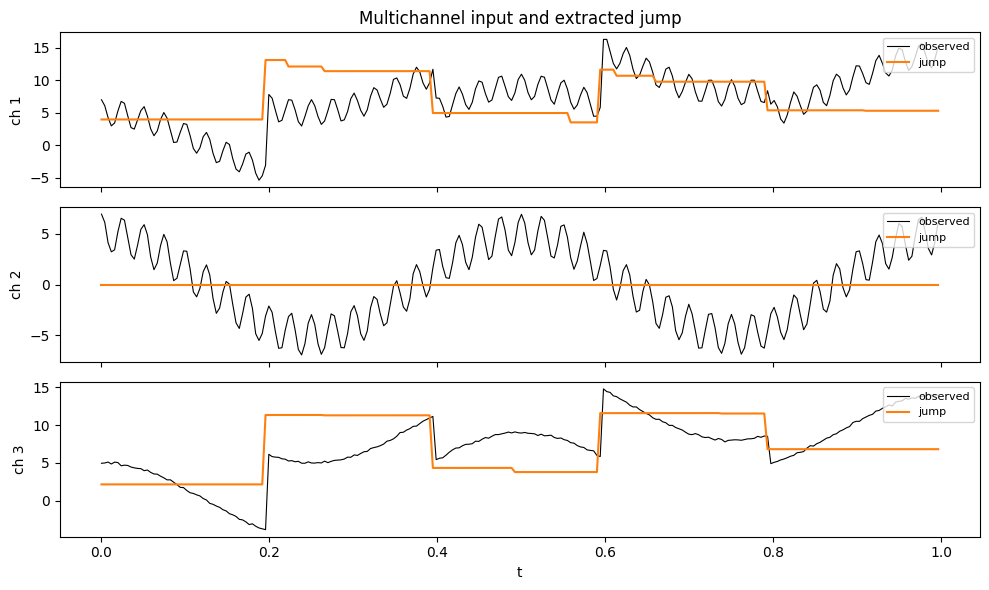

In [5]:
fig, axes = plt.subplots(Sig.shape[0], 1, figsize=(10, 6), sharex=True)
for c, ax in enumerate(axes):
    ax.plot(t, Sig[c], "k", lw=0.8, label="observed")
    ax.plot(t, J[c], "C1", lw=1.5, label="jump")
    ax.set_ylabel(f"ch {c+1}")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_title("Multichannel input and extracted jump")
axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

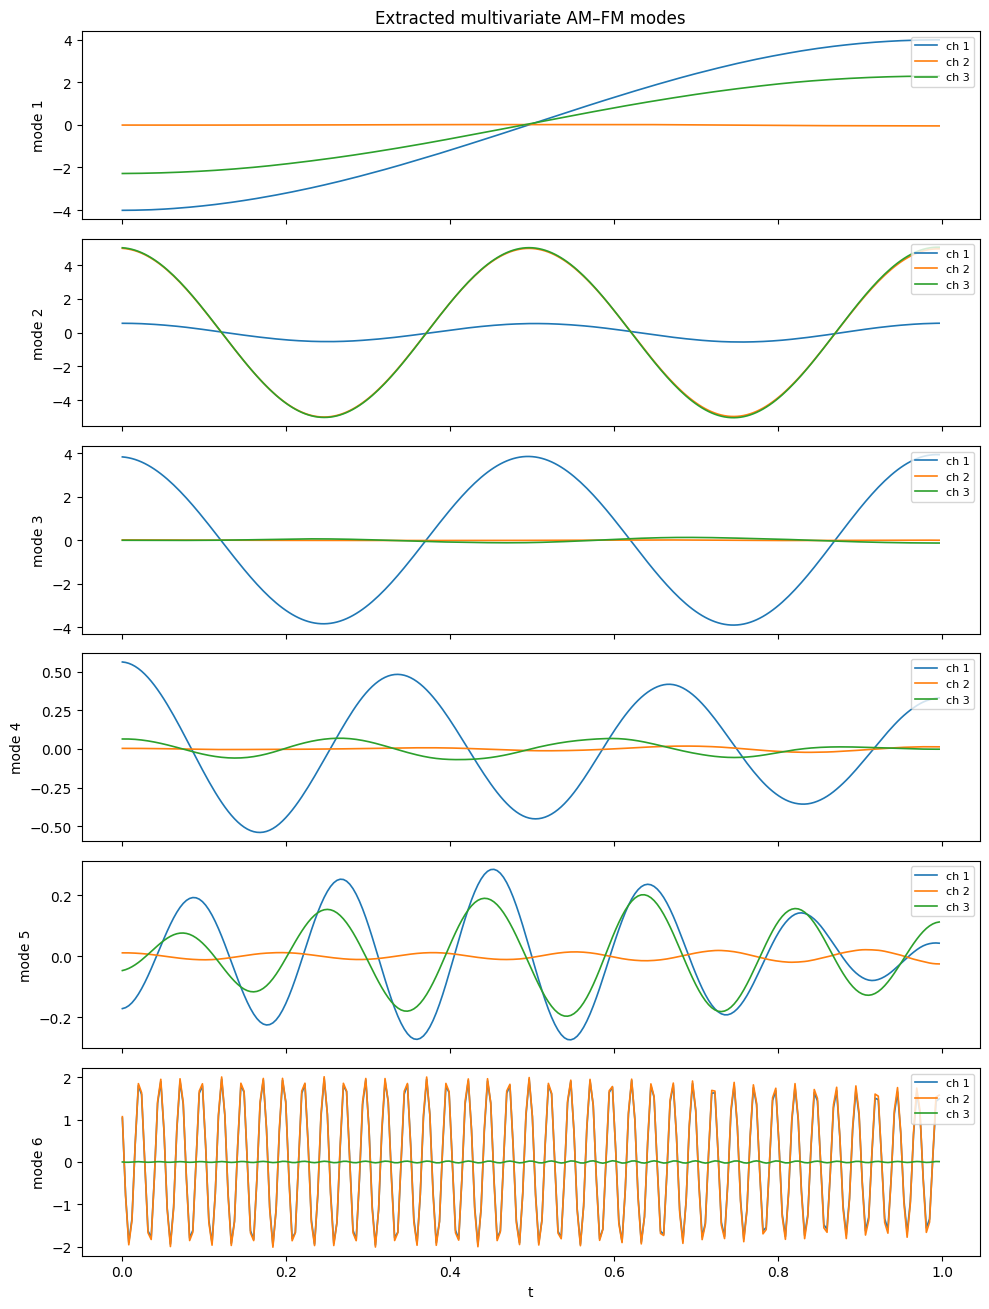

In [6]:
k = u.shape[0]
fig, axes = plt.subplots(k, 1, figsize=(10, 2.2 * k), sharex=True)
if k == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    for c in range(u.shape[2]):
        ax.plot(t, u[i, :, c], lw=1.2, label=f"ch {c+1}")
    ax.set_ylabel(f"mode {i+1}")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_title("Extracted multivariate AM–FM modes")
axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

## 3. Univariate example (SJMD)

Matches the single-channel setup commented in SJMD_test.m (intersecting tones + jump + noise).


In [7]:
rng = np.random.default_rng(1)
n = 512
t = np.arange(n, dtype=float) / n

sig1 = 4.0 * np.cos(2 * np.pi * 2 * t)
sig2 = 2.0 * np.cos(2 * np.pi * 40 * t)
sig3 = 2.0 * np.cos(2 * np.pi * 100 * t)

jump = np.zeros(n)
jump[n // 4 :] += 2.0
jump[n // 2 :] -= 1.5
jump[3 * n // 4 :] += 1.0
jump = 5.0 * jump / max(np.max(np.abs(jump)), 1.0)

noise = 0.1 * rng.standard_normal(n)
Sig = sig1 + sig2 + sig3 + jump + noise

In [8]:
sjmd_uni = SJMD(
    max_alpha=80000,
    tau=50,
    beta=0.5,
    b_bar=0.99,
    stopc=4,
    tol=1e-5,
)

u, v = sjmd_uni.fit_transform(Sig, return_all=True)
print("modes (K, N):", u.shape)
print("jump  (N,):  ", v.shape)
print("omega:       ", sjmd_uni.omega)

modes (K, N): (5, 512)
jump  (N,):   (512,)
omega:        [0.0039062  0.00471464 0.02176471 0.07811999 0.19531138]


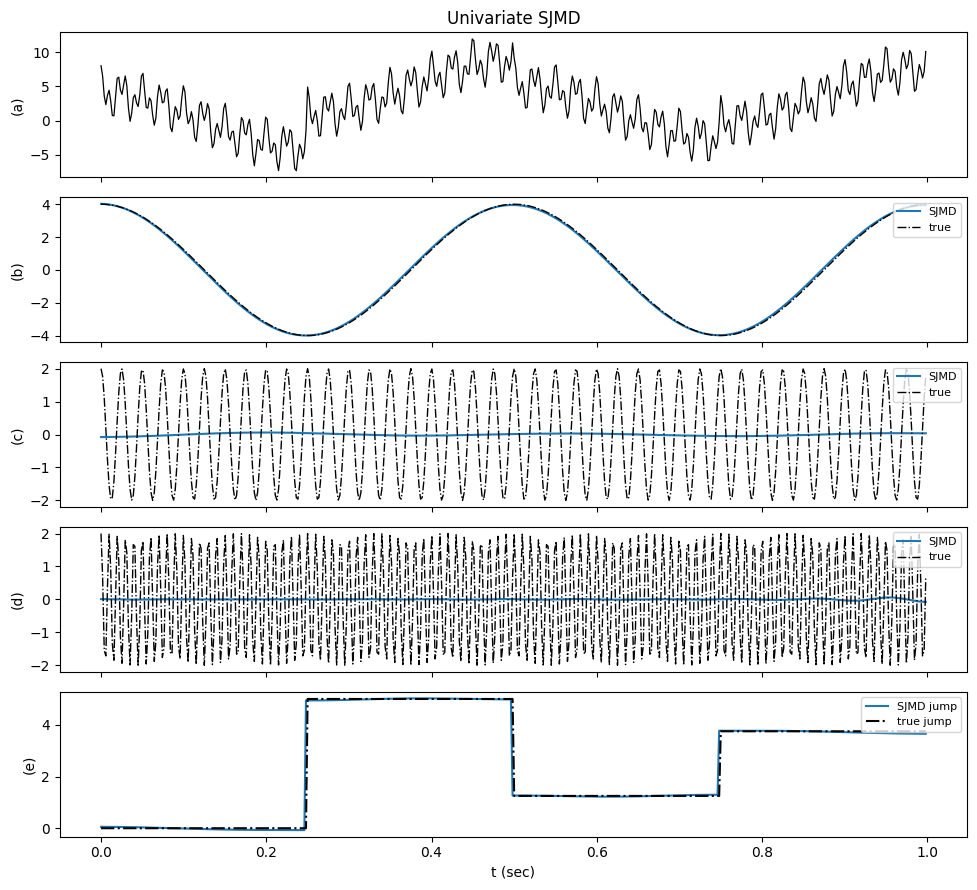

In [9]:
refs = [sig1, sig2, sig3]
n_show = min(u.shape[0], 3)
fig, axes = plt.subplots(n_show + 2, 1, figsize=(10, 1.8 * (n_show + 2)), sharex=True)

axes[0].plot(t, Sig, "k", lw=0.9)
axes[0].set_ylabel("(a)")
axes[0].set_title("Univariate SJMD")

for i in range(n_show):
    axes[i + 1].plot(t, u[i], lw=1.5, label="SJMD")
    if i < len(refs):
        axes[i + 1].plot(t, refs[i], "k-.", lw=1.0, label="true")
    axes[i + 1].set_ylabel(f"({chr(ord('b') + i)})")
    axes[i + 1].legend(loc="upper right", fontsize=8)

axes[-1].plot(t, v, lw=1.5, label="SJMD jump")
axes[-1].plot(t, jump, "k-.", lw=1.5, label="true jump")
axes[-1].set_ylabel(f"({chr(ord('b') + n_show)})")
axes[-1].set_xlabel("t (sec)")
axes[-1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## 4. Notes on stopping criteria

| stopc | Meaning |
|--------:|---------|
| 1 | Exact reconstruction (clean signals) |
| 2 | Bayesian / BIC |
| 3 | Extract exactly kdm dominant modes |
| 4 | Power of the last mode (**default / recommended**) |

For faster experiments you can use stopc=3, kdm=2 (or 3) instead of the automatic criterion.
